# Figures for the Loop Optimization Unit

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import xilinxutils
import xilinxutils.timing
import importlib
importlib.reload(xilinxutils)
importlib.reload(xilinxutils.timing)
from xilinxutils.timing import TimingDiagram, SigTimingInfo, ClkSig

import numpy as np

```systemverilog 
always_ff @(posedge clk) begin
  x_reg <= x;
end
always_comb begin
  xsq = x_reg * x_reg;
  xsq_w2 = w2 * xsq;
  x_w1 = w1 * x_reg;
  y = w0 + xsq_w2 + x_w1;
end
```

['x', 'x', '10', 'x', '-4', 'x', '8']
[0, np.float64(10.0), np.float64(10.5), np.float64(20.0), np.float64(20.5), np.float64(30.0), np.float64(30.5)]


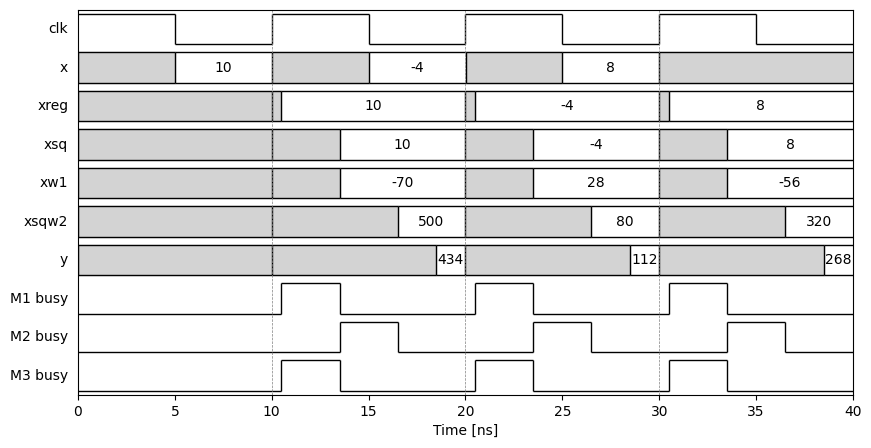

In [24]:
w = [4, -7, 5]



xvals = np.array([10, -4, 8])
xsqvals = xvals**2
xsqw2vals = w[2]*xsqvals
xw1vals = w[1]*xvals
yvals = w[0] + xsqw2vals + xw1vals
nin = len(xvals)

# Times
clk_period = 10
mdly = 3  # multiplier delay
adly = 1  # adder delay
regdly = 0.5  # register delay


# Create a clock signal
ncycles = 4
clk = ClkSig(clk_name="clk", period=clk_period, ncycles=ncycles)
p = clk.clk_periods()

# Convert to strings for plotting
xstr = ['x']
xreg = ['x']
xsq = ['x']
xw1 = ['x']
xsqw2 = ['x']
y = ['x']
input_times = [0]
xreg_times = [0]
xsq_times = [0]
xsqw2_times = [0]
y_times = [0]

m1act = ['0']
m1act_times = [0]
m2act = ['0']
m2act_times = [0]
for i in range(nin):
    xstr += [str(xvals[i]), 'x']
    xreg += ['x', str(xvals[i])]
    xreg_times += [p[i+1], p[i+1]+regdly]
    xsq += ['x', str(xvals[i])]
    xsq_times += [p[i+1], p[i+1]+regdly+mdly]
    xsqw2 += ['x', str(xsqw2vals[i])]
    xsqw2_times += [p[i+1], p[i+1]+regdly+2*mdly]
    m1act += ['1', '0']
    m1act_times += [p[i+1]+regdly, p[i+1]+regdly+mdly]
    m2act += ['1', '0']
    m2act_times += [p[i+1]+regdly+mdly, p[i+1]+regdly+2*mdly]
    input_times+= [p[i+1]-5, p[i+1]+0.01]

    xw1 += ['x', str(xw1vals[i])]
    y += ['x', str(yvals[i])]
    y_times += [p[i+1], p[i+1]+regdly+2*mdly+2*adly]

# Create timing diagram
disp_mactive = True
td = TimingDiagram()
td.add_signal(clk)
xsig = SigTimingInfo("x", input_times, xstr)
xregsig = SigTimingInfo("xreg", xreg_times, xreg)
xsqsig = SigTimingInfo("xsq", xsq_times, xsq)
xw1sig = SigTimingInfo("xw1", xsq_times, xw1)
xsqw2sig = SigTimingInfo("xsqw2", xsqw2_times, xsqw2)
ysig = SigTimingInfo("y", y_times, y)
m1actsig = SigTimingInfo("M1 busy", m1act_times, m1act)
m2actsig = SigTimingInfo("M2 busy", m2act_times, m2act)
m3actsig = SigTimingInfo("M3 busy", m1act_times, m2act)
td.add_signal(xsig)
td.add_signal(xregsig)
td.add_signal(xsqsig)
td.add_signal(xw1sig)
td.add_signal(xsqw2sig)
td.add_signal(ysig)
if disp_mactive:
    td.add_signals([m1actsig, m2actsig, m3actsig])
trange = [0, 40]
ax = td.plot_signals(trange=trange)
_ = ax.set_xlabel("Time [ns]")

print(xreg)
print(xreg_times)


## Two-Cycle Implementation

```systemverilog
always_ff @(posedge clk) begin
  x_reg <= x;
  xsq <= x_reg * x_reg;
  lin_term <= w1 * x_reg + w0;
end
always_comb begin
  y = w2 * xsq + lin_term;
end
```

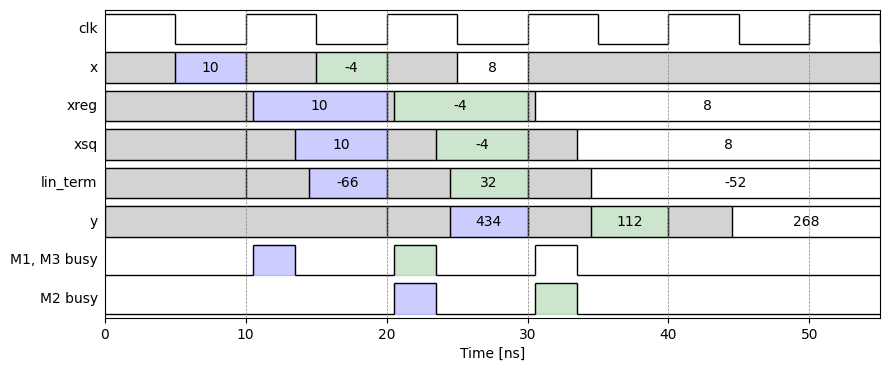

In [53]:
w = [4, -7, 5]

xvals = np.array([10, -4, 8])
nin = len(xvals)
xsqvals = xvals**2
linear_vals = w[1]*xvals + w[0]
yvals = linear_vals + w[2]*xsqvals

# Times
clk_period = 10


# Create a clock signal
ncycles = 6
clk = ClkSig(clk_name="clk", period=clk_period, ncycles=ncycles)
p = clk.clk_periods()

# Convert to strings for plotting
xstr = ['x']
xreg = ['x']
xsqstr = ['x']
xsqinstr = ['x']
lininstr = ['x']
linstr = ['x']
ystr = ['x']
input_times = [0]
xreg_times = [0]
xsq_times = [0]
lin_times = [0]
y_times = [0]
m1act = ['0']
m1act_times = [0]
m2act = ['0']
m2act_times = [0]
for i in range(nin):
    
    xstr += [str(xvals[i]), 'x']
    input_times+= [p[i+1]-5, p[i+1]+0.01]
    xreg += ['x', str(xvals[i])]
    xreg_times += [p[i+1], p[i+1]+regdly]
    xsqstr += ['x', str(xvals[i])]
    xsq_times += [p[i+1], p[i+1]+regdly+mdly]
    linstr += ['x', str(linear_vals[i])]
    lin_times += [p[i+1], p[i+1]+regdly+mdly+adly]

    y_times  += [p[i+2], p[i+2]+regdly+mdly+adly]
    ystr += ['x', str(yvals[i])]

    m1act += ['1', '0']
    m1act_times += [p[i+1]+regdly, p[i+1]+regdly+mdly]
    if (i > 0):
        m2act += ['1', '0']
        m2act_times += [p[i+1]+regdly, p[i+1]+regdly+mdly]

td = TimingDiagram()
td.add_signal(clk)
xsig = SigTimingInfo("x", input_times, xstr)
xregsig = SigTimingInfo("xreg", xreg_times, xreg)
xsqsig = SigTimingInfo("xsq", xsq_times, xsqstr)
linsig = SigTimingInfo("lin_term", lin_times, linstr)
ysig = SigTimingInfo("y", y_times, ystr)
m1actsig = SigTimingInfo("M1, M3 busy", m1act_times, m1act)
m2actsig = SigTimingInfo("M2 busy", m2act_times, m2act)
td.add_signal(xsig)
td.add_signal(xregsig)
td.add_signals([xsqsig, linsig, ysig, m1actsig, m2actsig])
ax = td.plot_signals()
_ = ax.set_xlabel("Time [ns]")



# Color the first iteration of the loop
sigs = ['x', 'xreg', 'xsq', 'lin_term', 'y', 'M1, M3 busy', 'M2 busy']
offsets = [0, 1, 1, 1, 1, 0, 0]
for sig, offset in zip(sigs, offsets):
    td.add_patch(sig, ind=1+offset, color='blue', alpha=0.2)
for sig, offset in zip(sigs, offsets):
    td.add_patch(sig, ind=3+offset, color='green', alpha=0.2)




In [56]:
print(3/5.5)

0.5454545454545454
